# 04 — Core Evaluation and Domain Shift Audit

**Purpose:** Generate test-set reports, compute the full metric stack, and run both domain shift audits.
Advanced prompt engineering strategies (RAG, association rules) live in notebooks 05 and 06.
Run notebook 04 first — its cached metric files are the input to the grand comparison in STEP 7.

**Checkpoints evaluated:**
- Zero-shot MedGemma 4B-it (no fine-tuning)
- `qlora_uniform_v3` — uniform sampling, BERTScore=0.7113
- `qlora_weighted_v4` — ESS-based weighted sampler, BERTScore=0.7036, macro-F1=0.0635

**Execution order across notebooks:**
```
04 (core eval)  →  05 (RAG)  →  06 (assoc. rules)  →  04 STEP 7 (grand comparison)
```

## STEP 1 — Environment setup

In [1]:
import os, sys, json, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import yaml

matplotlib.rcParams['figure.dpi'] = 120
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

PROCESSED_DIR  = REPO_ROOT / 'data' / 'processed'
CHECKPOINT_DIR = REPO_ROOT / 'checkpoints'
FIGURES_DIR    = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(REPO_ROOT / 'params.yaml') as f:
    params = yaml.safe_load(f)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {props.name}  {props.total_memory/1e9:.1f} GB')

test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
test_df = test_df[test_df['findings'].notna() & (test_df['findings'].str.strip() != '')].reset_index(drop=True)
references = test_df['findings'].str.strip().tolist()
print(f'Test set: {len(test_df)} studies')

env_file = REPO_ROOT / '.env'
if env_file.exists():
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())
    import huggingface_hub
    hf_token = os.environ.get('HF_TOKEN')
    if hf_token:
        huggingface_hub.login(token=hf_token, add_to_git_credential=False)
        print('HF: logged in')

Device : cuda
GPU    : NVIDIA RTX 4000 Ada Generation  21.0 GB
Test set: 600 studies


/home/jvazquez/diego_villalba/ReportCXR/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
WARNING Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF: logged in


## STEP 2 — Generate test-set reports for all fine-tuned variants

Greedy decoding (`temperature=0`) for reproducibility.  
Cached to `reports/eval_hypotheses_{variant}.json` — re-running skips generation.  
**~25–40 min per variant on Ada RTX 4000 (600 studies).**

In [2]:
from PIL import Image
from tqdm import tqdm
from src.training.model import load_model_and_processor

IMAGES_DIR = REPO_ROOT / params['data']['images_dir'] / 'images_normalized'
_BLANK = Image.new('RGB', (224, 224), color=(128, 128, 128))

SYSTEM_PROMPT = (
    'You are an expert radiologist. '
    'Write only the Findings section of a radiology report for the chest X-ray shown. '
    'Be concise and clinical. Do not include an Impression section.'
)

VARIANTS = {
    'zero_shot':   None,
    'uniform_v3':  'qlora_uniform_v3/best_model',
    'weighted_v4': 'qlora_weighted_v4/best_model',
}

def _load_image(row):
    frontal = row.get('frontal', [])
    if hasattr(frontal, '__len__') and len(frontal) > 0:
        p = IMAGES_DIR / list(frontal)[0]
        if p.exists():
            try: return Image.open(p).convert('RGB')
            except Exception: pass
    return _BLANK

def _generate_all(model, processor, df, cache_path):
    if cache_path.exists():
        hyps = json.loads(cache_path.read_text())
        print(f'  Loaded {len(hyps)} cached hypotheses from {cache_path.name}')
        return hyps
    hyps = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = _load_image(row)
        indication = str(row.get('indication', '') or '').strip()
        if indication.lower() in {'nan', 'none', ''}: indication = ''
        user_text = f'{SYSTEM_PROMPT}\nIndication: {indication}' if indication else SYSTEM_PROMPT
        content = [{'type': 'image'}, {'type': 'text', 'text': user_text}]
        prompt = processor.apply_chat_template(
            [{'role': 'user', 'content': content}],
            add_generation_prompt=True, tokenize=False,
        )
        inputs = processor(text=prompt, images=[img], return_tensors='pt', padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            out = model.generate(
                **inputs,
                max_new_tokens=params['model']['max_new_tokens'],
                do_sample=False,
                pad_token_id=processor.tokenizer.eos_token_id,
            )
        hyp = processor.tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
        ).strip()
        hyps.append(hyp)
    cache_path.write_text(json.dumps(hyps, ensure_ascii=False, indent=2))
    print(f'  Saved {len(hyps)} hypotheses to {cache_path.name}')
    return hyps

hypotheses = {}
for variant, adapter_rel in VARIANTS.items():
    cache = REPO_ROOT / 'reports' / f'eval_hypotheses_{variant}.json'
    print(f'\n[{variant}]')

    # Check cache BEFORE loading the model — avoids paying VRAM load cost unnecessarily
    if cache.exists():
        hypotheses[variant] = json.loads(cache.read_text())
        print(f'  Loaded {len(hypotheses[variant])} cached hypotheses (model not loaded)')
        continue

    model, processor = load_model_and_processor(
        model_id=params['model']['base_model_id'],
        quantization=params['model']['quantization'],
    )
    if adapter_rel is not None:
        adapter_path = CHECKPOINT_DIR / adapter_rel
        if not adapter_path.exists():
            print(f'  SKIP — checkpoint not found: {adapter_path}')
            del model, processor; torch.cuda.empty_cache(); continue
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, str(adapter_path))
    model.eval()
    hypotheses[variant] = _generate_all(model, processor, test_df, cache)
    del model, processor; torch.cuda.empty_cache()
    print(f'  Done. VRAM freed.')

print(f'\nVariants with hypotheses: {list(hypotheses.keys())}')


[zero_shot]
  Loaded 600 cached hypotheses (model not loaded)

[uniform_v3]
  Loaded 600 cached hypotheses (model not loaded)

[weighted_v4]
  Loaded 600 cached hypotheses (model not loaded)

Variants with hypotheses: ['zero_shot', 'uniform_v3', 'weighted_v4']


## STEP 3 — Full metric stack

- **BERTScore-F1** (primary) — `microsoft/deberta-xlarge-mnli`
- **CheXbert micro/macro F1** (diagnostic, vocabulary-artifact-affected on IU X-ray)
- **BLEU-4** and **ROUGE-L** (NLG comparability)

Cached to `reports/eval_metrics_{variant}.json` — picked up by notebooks 05/06 and STEP 7.

In [3]:
import bert_score.utils as _bsu
from bert_score import score as _bert_score
from src.data.labels import CHEXBERT_LABELS, run_chexbert
from sklearn.metrics import f1_score
import evaluate as hf_evaluate

_orig_sent_encode = _bsu.sent_encode
def _safe_sent_encode(tokenizer, sent):
    if getattr(tokenizer, 'model_max_length', 0) > 10_000:
        tokenizer.model_max_length = 512
    return _orig_sent_encode(tokenizer, sent)
_bsu.sent_encode = _safe_sent_encode

_bleu  = hf_evaluate.load('bleu')
_rouge = hf_evaluate.load('rouge')

def _compute_metrics(hyps, refs, variant, uncertain_policy='present'):
    cache = REPO_ROOT / 'reports' / f'eval_metrics_{variant}.json'
    if cache.exists():
        print(f'  [{variant}] loaded from cache')
        return json.loads(cache.read_text())
    print(f'  [{variant}] BERTScore…')
    _, _, F = _bert_score(hyps, refs,
        model_type=params['eval']['bertscore_model'],
        lang='en', device=DEVICE, verbose=False, batch_size=16)
    print(f'  [{variant}] CheXbert…')
    hyp_labels = run_chexbert(hyps, uncertain_policy=uncertain_policy, device=DEVICE)
    ref_labels = run_chexbert(refs, uncertain_policy=uncertain_policy, device=DEVICE)
    print(f'  [{variant}] BLEU/ROUGE…')
    result = {
        'variant': variant,
        'bertscore_f1':      float(F.mean()),
        'chexbert_micro_f1': float(f1_score(ref_labels, hyp_labels, average='micro', zero_division=0)),
        'chexbert_macro_f1': float(f1_score(ref_labels, hyp_labels, average='macro', zero_division=0)),
        'bleu4':             _bleu.compute(predictions=hyps, references=[[r] for r in refs], max_order=4)['bleu'],
        'rouge_l':           _rouge.compute(predictions=hyps, references=refs)['rougeL'],
        'per_label_f1':      {label: float(f1_score(ref_labels[:, i], hyp_labels[:, i], zero_division=0))
                              for i, label in enumerate(CHEXBERT_LABELS)},
        'bertscore_per_study': F.tolist(),
    }
    cache.write_text(json.dumps(result, indent=2))
    print(f'  [{variant}] saved → {cache.name}')
    return result

metrics = {}
zs_baseline = REPO_ROOT / 'reports' / 'baseline_results.json'
if zs_baseline.exists():
    raw = json.loads(zs_baseline.read_text())
    m = raw['metrics']
    metrics['zero_shot'] = {
        'variant': 'zero_shot',
        'bertscore_f1':       m.get('bertscore_f1', float('nan')),
        'chexbert_micro_f1':  m.get('f1_chexbert_micro_present', float('nan')),
        'chexbert_macro_f1':  m.get('f1_chexbert_macro_present', float('nan')),
        'bleu4':              m.get('bleu4', float('nan')),
        'rouge_l':            m.get('rouge_l', float('nan')),
        'per_label_f1':       m.get('per_label_f1_present', {}),
        'bertscore_per_study': raw.get('bertscore_per_study', []),
    }
    print('[zero_shot] loaded from baseline_results.json')

for variant, hyps in hypotheses.items():
    if variant == 'zero_shot' and 'zero_shot' in metrics:
        continue
    metrics[variant] = _compute_metrics(hyps, references, variant)

_bsu.sent_encode = _orig_sent_encode
print('\nDone. Variants evaluated:', list(metrics.keys()))

[zero_shot] loaded from baseline_results.json
  [uniform_v3] loaded from cache
  [weighted_v4] loaded from cache

Done. Variants evaluated: ['zero_shot', 'uniform_v3', 'weighted_v4']


## STEP 4 — Fine-tuning comparison table and figures

,BERTScore-F1,CheXbert micro-F1,CheXbert macro-F1,BLEU-4,ROUGE-L
Model,,,,,
Zero-shot MedGemma,0.6938,0.3967,0.1416,0.0957,0.2631
QLoRA uniform (v3),0.6925,0.4637,0.1651,0.1145,0.2915
QLoRA weighted (v4),0.6784,0.4423,0.1786,0.0829,0.2740


Saved eval_metric_summary.png


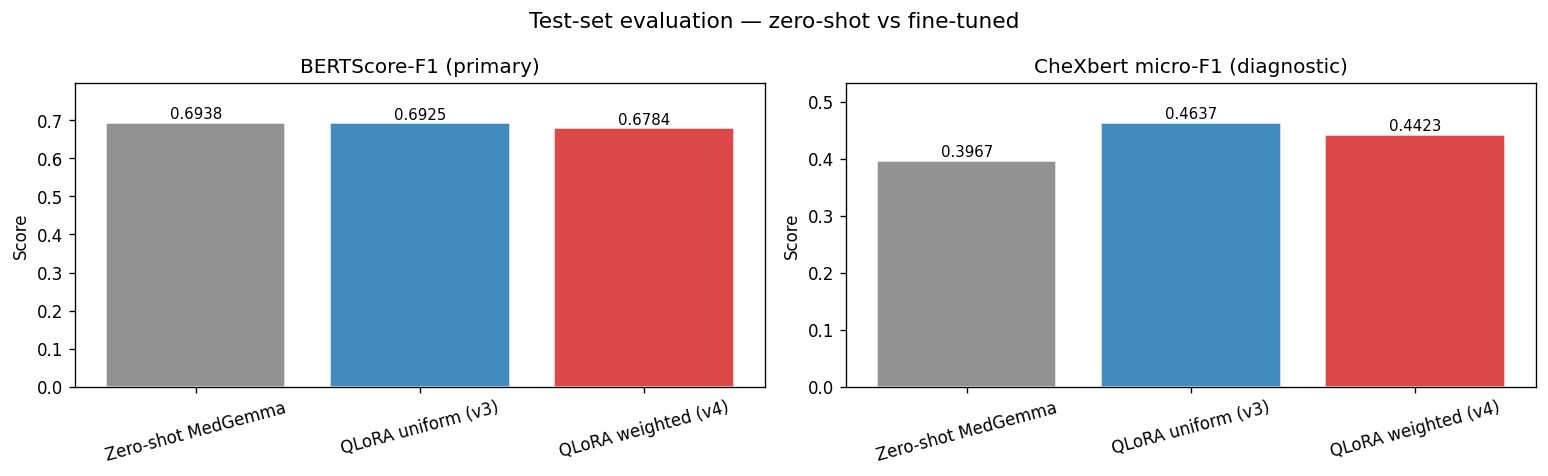

Saved eval_per_label_f1.png


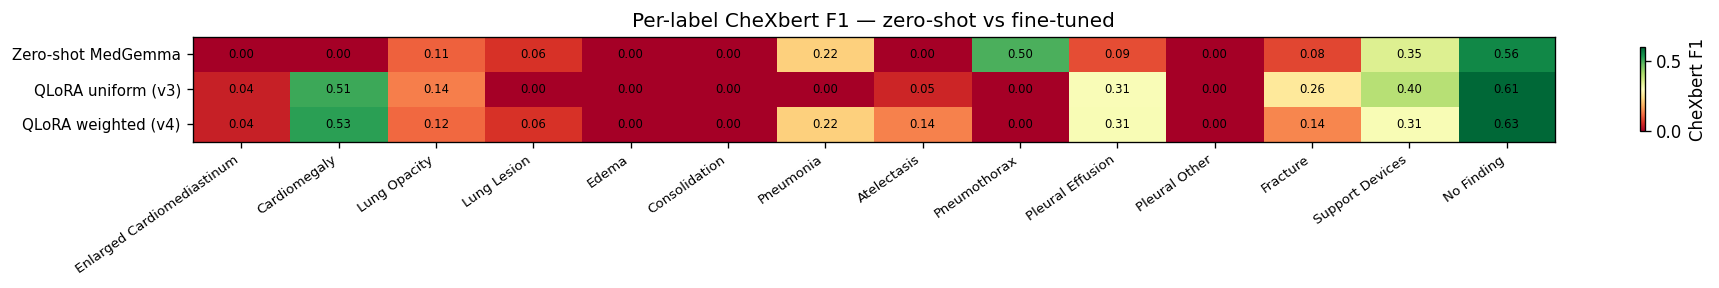

In [4]:
DISPLAY_NAMES = {
    'zero_shot':   'Zero-shot MedGemma',
    'uniform_v3':  'QLoRA uniform (v3)',
    'weighted_v4': 'QLoRA weighted (v4)',
}
METRIC_KEY = {
    'BERTScore-F1':      'bertscore_f1',
    'CheXbert micro-F1': 'chexbert_micro_f1',
    'CheXbert macro-F1': 'chexbert_macro_f1',
    'BLEU-4':            'bleu4',
    'ROUGE-L':           'rouge_l',
}

rows = []
for variant in ('zero_shot', 'uniform_v3', 'weighted_v4'):
    if variant not in metrics: continue
    m = metrics[variant]
    rows.append({'Model': DISPLAY_NAMES.get(variant, variant),
                 **{col: round(m[key], 4) for col, key in METRIC_KEY.items()}})
summary_df = pd.DataFrame(rows).set_index('Model')
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#7f7f7f', '#1f77b4', '#d62728']
active = [v for v in ('zero_shot', 'uniform_v3', 'weighted_v4') if v in metrics]
names  = [DISPLAY_NAMES[v] for v in active]

for ax, (col, key), title in [
    (axes[0], ('BERTScore-F1', 'bertscore_f1'),      'BERTScore-F1 (primary)'),
    (axes[1], ('CheXbert micro-F1', 'chexbert_micro_f1'), 'CheXbert micro-F1 (diagnostic)'),
]:
    vals = [metrics[v][key] for v in active]
    bars = ax.bar(names, vals, color=colors[:len(vals)], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.set_title(title); ax.set_ylabel('Score')
    ax.tick_params(axis='x', labelrotation=15)

plt.suptitle('Test-set evaluation — zero-shot vs fine-tuned', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_metric_summary.png', dpi=150, bbox_inches='tight')
print('Saved eval_metric_summary.png'); plt.show()

# Per-label F1 heatmap
label_rows = []
for variant in active:
    per_label = metrics[variant].get('per_label_f1', {})
    label_rows.append({'Model': DISPLAY_NAMES[variant], **{k: round(v, 3) for k, v in per_label.items()}})
if label_rows:
    ldf = pd.DataFrame(label_rows).set_index('Model')
    fig, ax = plt.subplots(figsize=(16, 2.5))
    im = ax.imshow(ldf.values, cmap='RdYlGn', vmin=0, vmax=0.6, aspect='auto')
    ax.set_xticks(range(len(ldf.columns))); ax.set_xticklabels(ldf.columns, rotation=35, ha='right', fontsize=8)
    ax.set_yticks(range(len(ldf.index))); ax.set_yticklabels(ldf.index, fontsize=9)
    for i in range(len(ldf.index)):
        for j in range(len(ldf.columns)):
            ax.text(j, i, f'{ldf.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label='CheXbert F1')
    ax.set_title('Per-label CheXbert F1 — zero-shot vs fine-tuned')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eval_per_label_f1.png', dpi=150, bbox_inches='tight')
    print('Saved eval_per_label_f1.png'); plt.show()

## STEP 5 — Domain Shift Audit: Acquisition Shift

Sweeps 5 image perturbation types across their magnitude grids and measures BERTScore degradation.
Simulates equipment-level shift (different vendor calibration, kVp, digitization quality).

**Perturbations:** brightness · contrast · gamma · gaussian_noise · jpeg_compression

In [5]:
from src.domain_shift_audit.acquisition_shift import run_acquisition_sweep, DEFAULT_MAGNITUDES
from peft import PeftModel

AUDIT_VARIANT = 'uniform_v3'

print(f'Loading {AUDIT_VARIANT} for acquisition audit…')
audit_model, audit_proc = load_model_and_processor(
    model_id=params['model']['base_model_id'],
    quantization=params['model']['quantization'],
)
adapter_path = CHECKPOINT_DIR / AUDIT_VARIANT / 'best_model'
if not adapter_path.exists():
    adapter_path = CHECKPOINT_DIR / f'qlora_{AUDIT_VARIANT}' / 'best_model'
audit_model = PeftModel.from_pretrained(audit_model, str(adapter_path))
audit_model.eval()

print('Loading test images…')
test_images = [_load_image(row) for _, row in test_df.iterrows()]

def _bertscore_metric_fn(perturbed_images):
    import bert_score.utils as _bsu2
    from bert_score import score as _bert_score2
    _bsu2.sent_encode = _safe_sent_encode
    hyps = []
    for img, (_, row) in zip(perturbed_images, test_df.iterrows()):
        indication = str(row.get('indication', '') or '').strip()
        if indication.lower() in {'nan', 'none', ''}: indication = ''
        user_text = f'{SYSTEM_PROMPT}\nIndication: {indication}' if indication else SYSTEM_PROMPT
        content = [{'type': 'image'}, {'type': 'text', 'text': user_text}]
        prompt = audit_proc.apply_chat_template(
            [{'role': 'user', 'content': content}],
            add_generation_prompt=True, tokenize=False,
        )
        inputs = audit_proc(text=prompt, images=[img], return_tensors='pt', padding=True)
        inputs = {k: v.to(audit_model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            out = audit_model.generate(**inputs,
                max_new_tokens=params['model']['max_new_tokens'],
                do_sample=False, pad_token_id=audit_proc.tokenizer.eos_token_id)
        hyp = audit_proc.tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        hyps.append(hyp)
    _, _, F = _bert_score2(hyps, references,
        model_type=params['eval']['bertscore_model'],
        lang='en', device=DEVICE, verbose=False, batch_size=16)
    return float(F.mean())

acq_results = {}
for perturb_type in DEFAULT_MAGNITUDES:
    cache = REPO_ROOT / 'reports' / f'acq_shift_{AUDIT_VARIANT}_{perturb_type}.json'
    if cache.exists():
        acq_results[perturb_type] = json.loads(cache.read_text())
        print(f'  {perturb_type}: loaded from cache')
    else:
        print(f'  {perturb_type}: sweeping…')
        res = run_acquisition_sweep(
            images=test_images, perturb_type=perturb_type,
            metric_fn=_bertscore_metric_fn, metric_name='bertscore_f1',
        )
        data = res.to_dataframe().to_dict(orient='list')
        cache.write_text(json.dumps(data))
        acq_results[perturb_type] = data
        print(f'  {perturb_type}: done')

del audit_model, audit_proc; torch.cuda.empty_cache()
print('VRAM freed.')

INFO Loading processor from google/medgemma-4b-it


Loading uniform_v3 for acquisition audit…


INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: GET https://huggingface.co/api/models/google/medgemma-4b-it/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"


INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/chat_template.jinja "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: GET https://huggingface.co/api/models/google/medgemma-4b-it/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/mai

Loading test images…
  brightness: loaded from cache
  contrast: loaded from cache
  gamma: loaded from cache
  gaussian_noise: loaded from cache
  jpeg_compression: loaded from cache
VRAM freed.


Saved eval_acquisition_shift.png


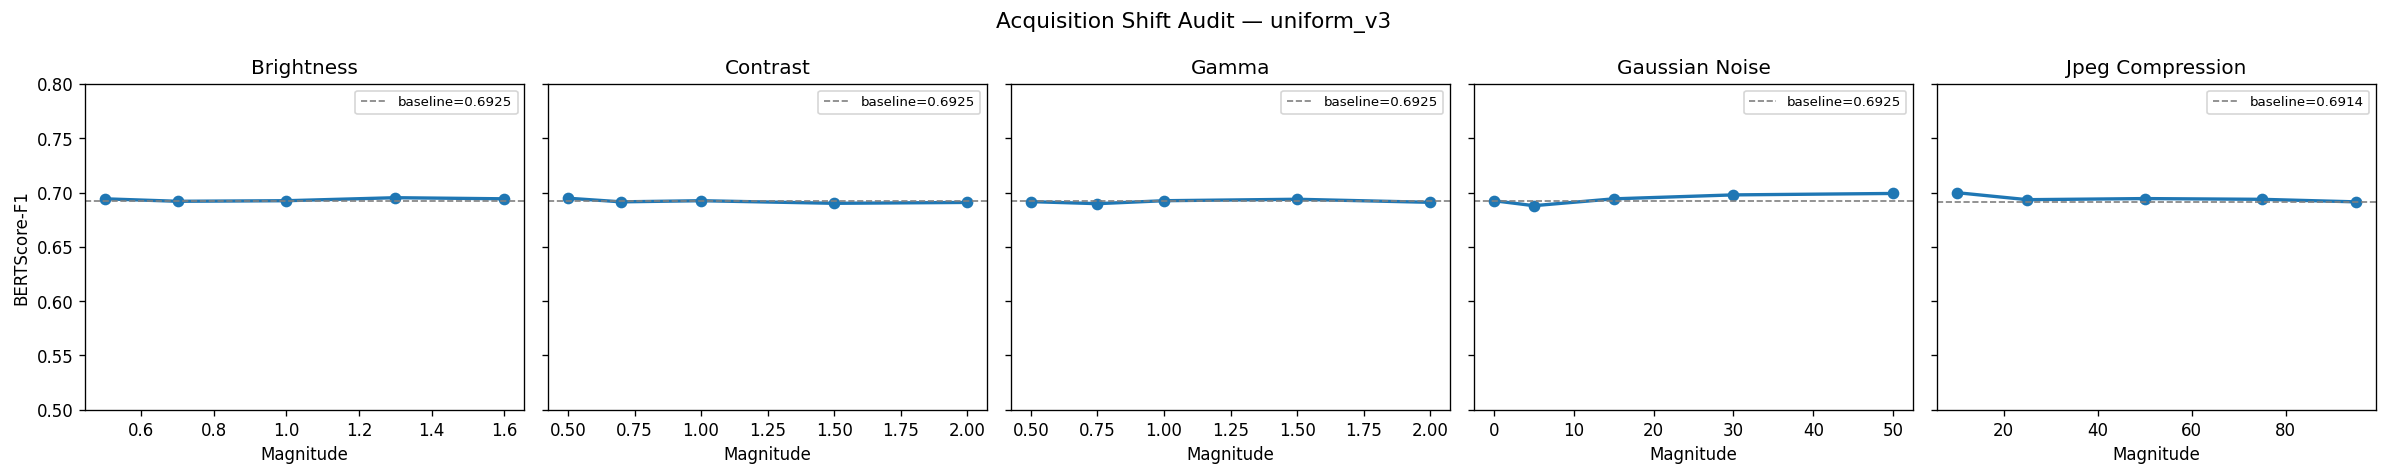

In [6]:
fig, axes = plt.subplots(1, len(acq_results), figsize=(4 * len(acq_results), 4), sharey=True)
if len(acq_results) == 1: axes = [axes]
for ax, (perturb_type, data) in zip(axes, acq_results.items()):
    df = pd.DataFrame(data)
    ax.plot(df['magnitude'], df['bertscore_f1'], marker='o', color='#1f77b4', linewidth=2)
    rel = df['relative_degradation'].abs()
    if (rel < 0.001).any():
        baseline = float(df.loc[rel.idxmin(), 'bertscore_f1'])
        ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, label=f'baseline={baseline:.4f}')
        ax.legend(fontsize=8)
    ax.set_title(perturb_type.replace('_', ' ').title())
    ax.set_xlabel('Magnitude')
    if ax is axes[0]: ax.set_ylabel('BERTScore-F1')
    ax.set_ylim(0.5, 0.80)
plt.suptitle(f'Acquisition Shift Audit — {AUDIT_VARIANT}', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_acquisition_shift.png', dpi=150, bbox_inches='tight')
print('Saved eval_acquisition_shift.png'); plt.show()

## STEP 6 — Domain Shift Audit: Prevalence Shift (Importance Sampling)

Estimates performance under a different label distribution (e.g. higher Pleural Effusion prevalence —
plausible for a LATAM deployment). Uses importance-sampling re-weighting:  
`w_i = π_target(y_i) / π_source(y_i)`,  `weighted_score = Σ w_i·score_i / Σ w_i`  
Dashed lines = ESS < 30 (estimate unreliable).

Pleural Effusion: source prevalence = 0.032
Atelectasis: source prevalence = 0.067
Pneumonia: source prevalence = 0.010
Consolidation: source prevalence = 0.007
Saved eval_prevalence_shift.png


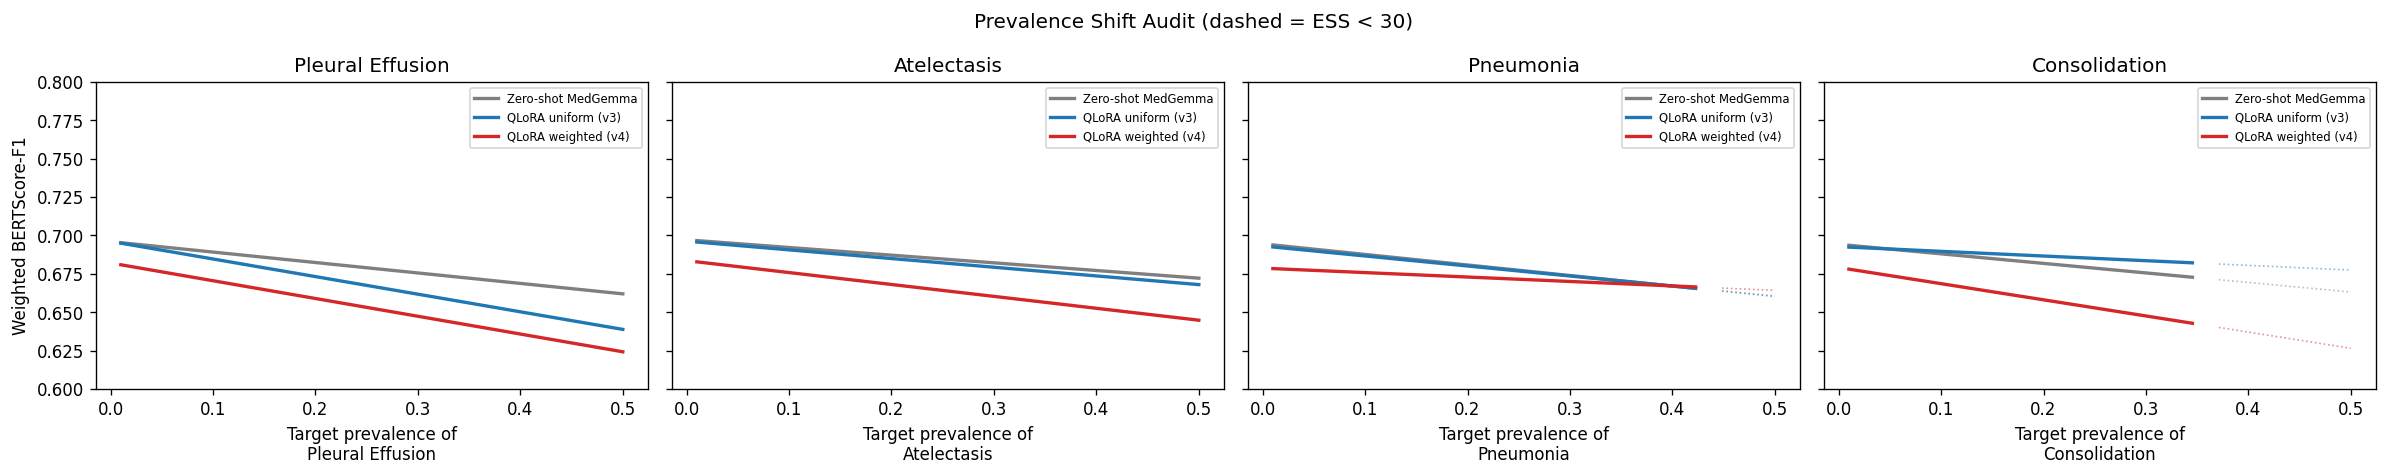

In [7]:
from src.data.labels import CHEXBERT_LABELS

SHIFT_LABELS = ['Pleural Effusion', 'Atelectasis', 'Pneumonia', 'Consolidation']
test_label_matrix = test_df[CHEXBERT_LABELS].values.astype(float)

def _importance_weights(label_matrix, label_idx, pi_target, pi_source):
    y = label_matrix[:, label_idx]
    return np.where(y == 1,
        pi_target / max(pi_source, 1e-9),
        (1 - pi_target) / max(1 - pi_source, 1e-9)
    ).astype(np.float64)

def _ess(weights):
    w = weights / weights.sum()
    return float(1.0 / (w**2).sum())

pi_targets = np.linspace(0.01, 0.50, 20)
prev_results = {}
for label in SHIFT_LABELS:
    label_idx = CHEXBERT_LABELS.index(label)
    pi_source = float(test_label_matrix[:, label_idx].mean())
    rows = []
    for variant in ('zero_shot', 'uniform_v3', 'weighted_v4'):
        if variant not in metrics: continue
        scores = np.array(metrics[variant].get('bertscore_per_study', []))
        if len(scores) != len(test_label_matrix): continue
        for pi_t in pi_targets:
            w = _importance_weights(test_label_matrix, label_idx, pi_t, pi_source)
            ess_val = _ess(w)
            rows.append({'variant': variant,
                         'target_prevalence': round(float(pi_t), 4),
                         'weighted_bertscore_f1': float(np.average(scores, weights=w)),
                         'ess': ess_val, 'reliable': ess_val >= 30})
    prev_results[label] = pd.DataFrame(rows)
    print(f'{label}: source prevalence = {pi_source:.3f}')

palette = {'zero_shot': '#7f7f7f', 'uniform_v3': '#1f77b4', 'weighted_v4': '#d62728'}
fig, axes = plt.subplots(1, len(SHIFT_LABELS), figsize=(5 * len(SHIFT_LABELS), 4), sharey=True)
for ax, label in zip(axes, SHIFT_LABELS):
    df = prev_results[label]
    for variant, color in palette.items():
        vdf = df[df['variant'] == variant]
        r, u = vdf[vdf['reliable']], vdf[~vdf['reliable']]
        if len(r): ax.plot(r['target_prevalence'], r['weighted_bertscore_f1'],
                           color=color, linewidth=2, label=DISPLAY_NAMES.get(variant, variant))
        if len(u): ax.plot(u['target_prevalence'], u['weighted_bertscore_f1'],
                           color=color, linewidth=1, linestyle=':', alpha=0.5)
    ax.set_xlabel(f'Target prevalence of\n{label}')
    ax.set_title(label); ax.legend(fontsize=7); ax.set_ylim(0.60, 0.80)
axes[0].set_ylabel('Weighted BERTScore-F1')
plt.suptitle('Prevalence Shift Audit (dashed = ESS < 30)', fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_prevalence_shift.png', dpi=150, bbox_inches='tight')
print('Saved eval_prevalence_shift.png'); plt.show()

## STEP 7 — Grand Comparison (all variants)

Auto-discovers every `reports/eval_metrics_*.json` file — including those produced by notebooks 05 (RAG)
and 06 (association rules). Run this cell last, after all other notebooks have completed.

**Execution order:** 04 STEPs 1-6 → notebook 05 → notebook 06 → this cell.

  Assoc. rules (v3): BERTScore=0.6844
  assoc_rules_weighted_v4: BERTScore=0.6862
  nohint_uniform_v3: BERTScore=0.6879
  nohint_weighted_v4: BERTScore=0.6876
  RAG + Assoc. rules (v3): BERTScore=0.7033
  rag_assoc_combined_weighted_v4: BERTScore=0.7019
  RAG k=3 (v3): BERTScore=0.7076
  QLoRA uniform (v3): BERTScore=0.6925
  QLoRA weighted (v4): BERTScore=0.6784
  Zero-shot MedGemma: BERTScore=0.6938


,BERTScore-F1,CheXbert micro-F1,CheXbert macro-F1,BLEU-4,ROUGE-L
Model,,,,,
RAG k=3 (v3),0.7076,0.3432,0.1160,0.1391,0.3051
RAG + Assoc. rules (v3),0.7033,0.2567,0.0954,0.1337,0.2870
rag_assoc_combined_weighted_v4,0.7019,0.2694,0.1037,0.1352,0.2842
Zero-shot MedGemma,0.6938,0.3967,0.1416,0.0957,0.2631
QLoRA uniform (v3),0.6925,0.4637,0.1651,0.1145,0.2915
nohint_uniform_v3,0.6879,0.4404,0.1445,0.1128,0.2852
nohint_weighted_v4,0.6876,0.4526,0.1581,0.1076,0.2720
assoc_rules_weighted_v4,0.6862,0.4559,0.1841,0.1073,0.2713
Assoc. rules (v3),0.6844,0.4424,0.1745,0.1100,0.2812


Saved eval_grand_comparison.png


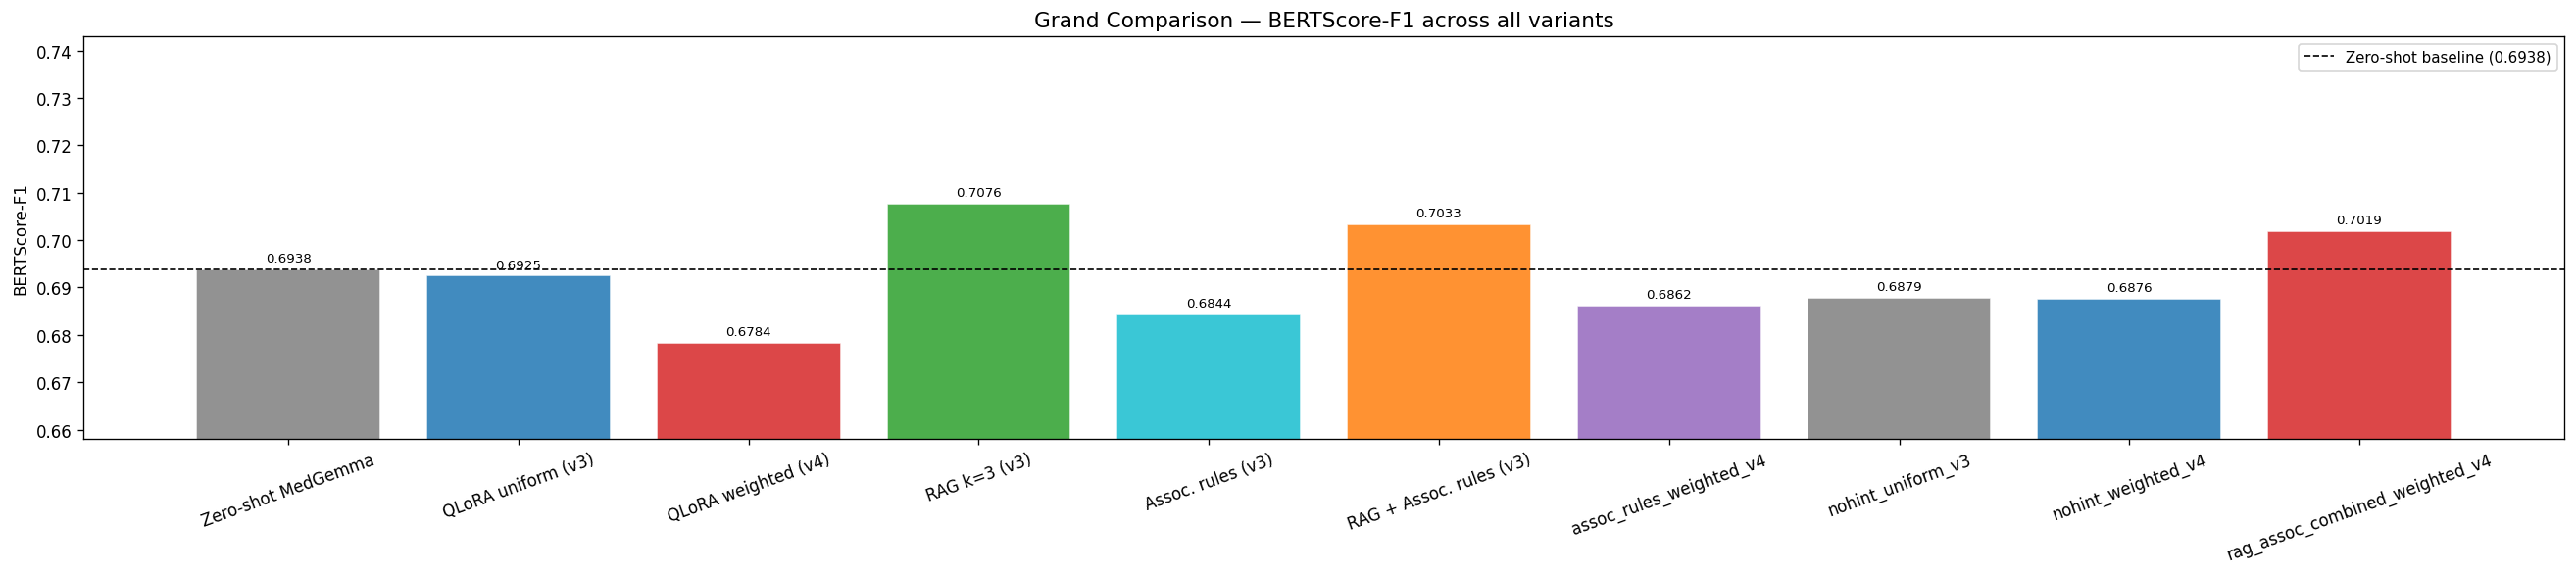

In [8]:
# ── Friendly display names for all known variant keys ─────────────────────────
ALL_DISPLAY_NAMES = {
    'zero_shot':                   'Zero-shot MedGemma',
    'uniform_v3':                  'QLoRA uniform (v3)',
    'weighted_v4':                 'QLoRA weighted (v4)',
    'rag_k3_uniform_v3':           'RAG k=3 (v3)',
    'rag_k5_uniform_v3':           'RAG k=5 (v3)',
    'assoc_rules_uniform_v3':      'Assoc. rules (v3)',
    'rag_assoc_combined_uniform_v3': 'RAG + Assoc. rules (v3)',
}

# ── Scan all cached metric files ──────────────────────────────────────────────
all_metrics = {}
for f in sorted((REPO_ROOT / 'reports').glob('eval_metrics_*.json')):
    variant = f.stem.replace('eval_metrics_', '')
    data = json.loads(f.read_text())
    all_metrics[variant] = data
    display_name = ALL_DISPLAY_NAMES.get(variant, variant)
    print(f'  {display_name}: BERTScore={data["bertscore_f1"]:.4f}')

if not all_metrics:
    print('No eval_metrics_*.json files found — run STEPs 1–6 first.')
else:
    rows = []
    for variant, m in sorted(all_metrics.items(), key=lambda x: -x[1]['bertscore_f1']):
        rows.append({
            'Model':             ALL_DISPLAY_NAMES.get(variant, variant),
            'BERTScore-F1':      round(m['bertscore_f1'],      4),
            'CheXbert micro-F1': round(m['chexbert_micro_f1'], 4),
            'CheXbert macro-F1': round(m['chexbert_macro_f1'], 4),
            'BLEU-4':            round(m['bleu4'],             4),
            'ROUGE-L':           round(m['rouge_l'],           4),
        })
    grand_df = pd.DataFrame(rows).set_index('Model')
    display(grand_df)

    # ── Grand comparison bar chart ────────────────────────────────────────────
    ordered_variants = [v for v in (
        'zero_shot', 'uniform_v3', 'weighted_v4',
        'rag_k3_uniform_v3', 'rag_k5_uniform_v3',
        'assoc_rules_uniform_v3', 'rag_assoc_combined_uniform_v3',
    ) if v in all_metrics]
    other_variants = [v for v in all_metrics if v not in ordered_variants]
    ordered_variants += other_variants

    names = [ALL_DISPLAY_NAMES.get(v, v) for v in ordered_variants]
    bscore = [all_metrics[v]['bertscore_f1'] for v in ordered_variants]
    palette_grand = ['#7f7f7f', '#1f77b4', '#d62728', '#2ca02c', '#17becf', '#ff7f0e', '#9467bd']
    colors_grand = (palette_grand * 4)[:len(ordered_variants)]

    fig, ax = plt.subplots(figsize=(max(8, 2.2 * len(ordered_variants)), 5))
    bars = ax.bar(names, bscore, color=colors_grand, alpha=0.85, edgecolor='white')
    baseline_score = all_metrics.get('zero_shot', {}).get('bertscore_f1')
    if baseline_score:
        ax.axhline(baseline_score, color='black', linestyle='--', linewidth=1,
                   label=f'Zero-shot baseline ({baseline_score:.4f})')
        ax.legend(fontsize=9)
    for bar, val in zip(bars, bscore):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_ylim(min(bscore) * 0.97, max(bscore) * 1.05)
    ax.set_ylabel('BERTScore-F1')
    ax.set_title('Grand Comparison — BERTScore-F1 across all variants', fontsize=13)
    ax.tick_params(axis='x', labelrotation=20)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eval_grand_comparison.png', dpi=150, bbox_inches='tight')
    print('Saved eval_grand_comparison.png'); plt.show()

Saved eval_scatter_fluency_vs_coverage.png


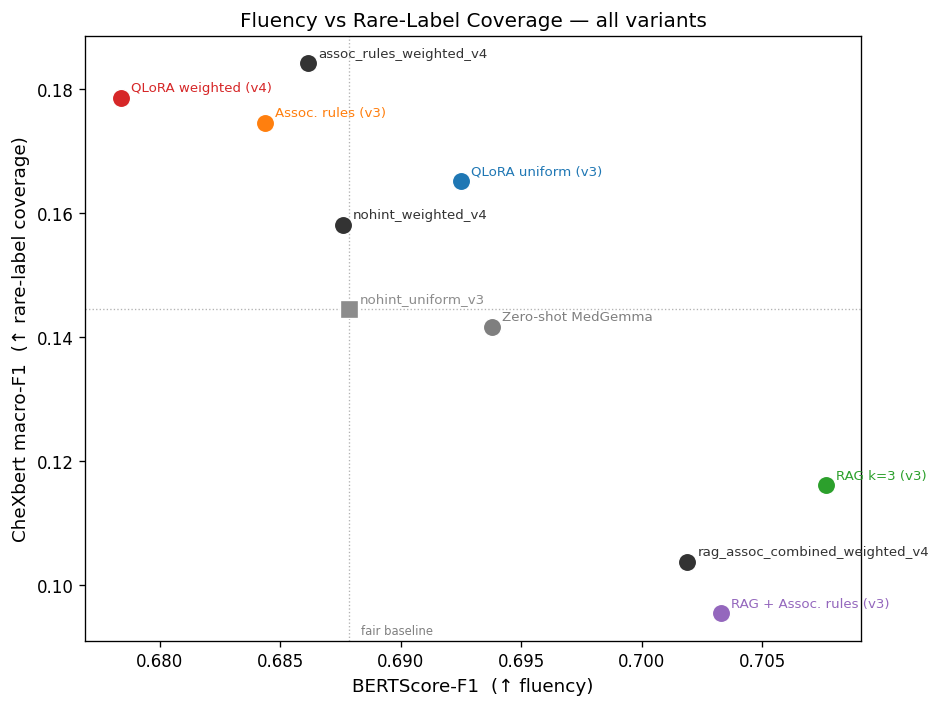

Saved eval_per_label_heatmap.png


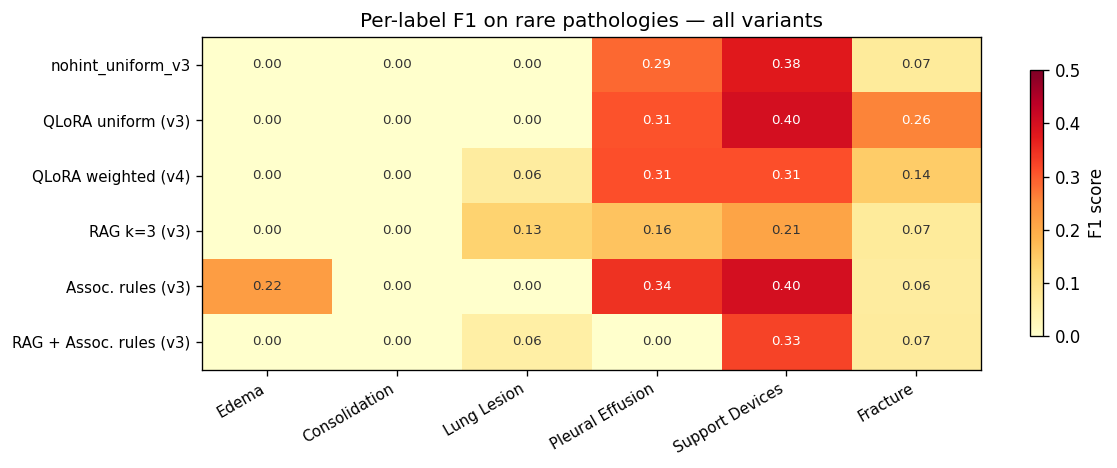

Saved eval_delta_from_baseline.png


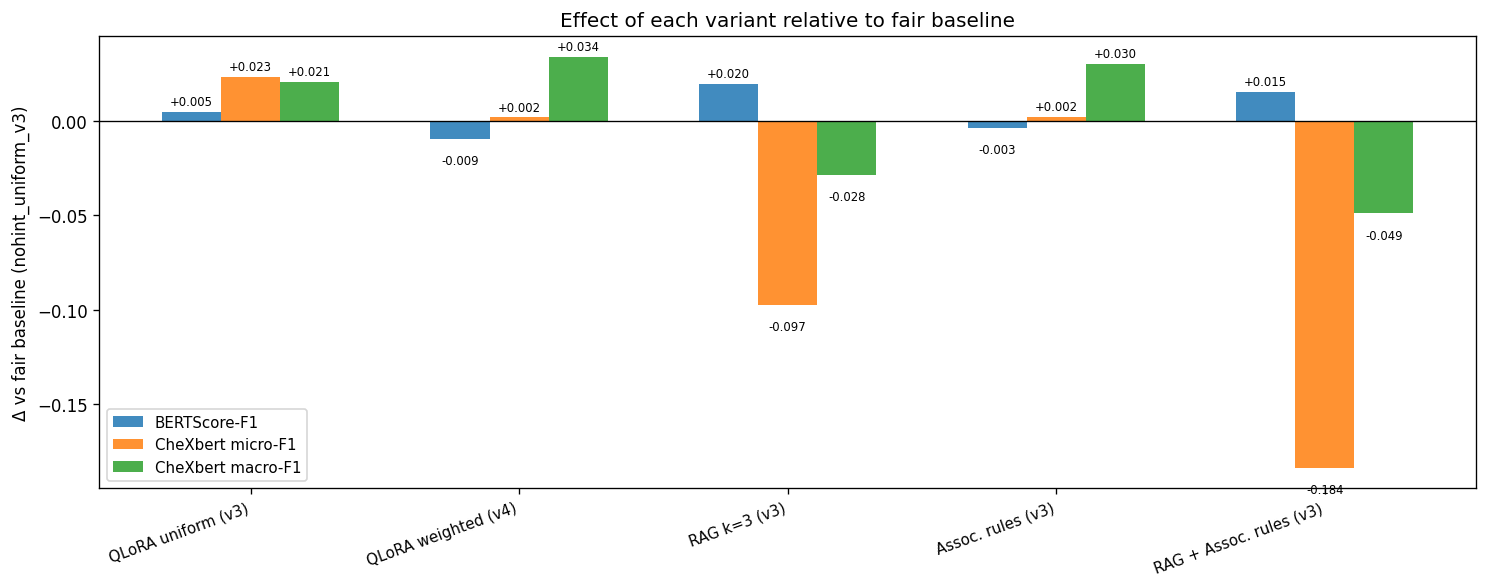

In [9]:
# ─── STEP 7b — Additional comparison charts ────────────────────────────────

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

FAIR_BASELINE = 'nohint_uniform_v3'
RARE_LABELS   = ['Edema', 'Consolidation', 'Lung Lesion',
                  'Pleural Effusion', 'Support Devices', 'Fracture']

# 1. BERTScore vs CheXbert macro-F1 scatter ─────────────────────────────────
# Core trade-off story: fluency and rare-label coverage are in tension.
fig, ax = plt.subplots(figsize=(8, 6))
palette = {
    'zero_shot':                     '#7f7f7f',
    'uniform_v3':                    '#1f77b4',
    'weighted_v4':                   '#d62728',
    'rag_k3_uniform_v3':             '#2ca02c',
    'assoc_rules_uniform_v3':        '#ff7f0e',
    'rag_assoc_combined_uniform_v3': '#9467bd',
    'nohint_uniform_v3':             '#8c8c8c',
}
for variant, m in all_metrics.items():
    x = m['bertscore_f1']
    y = m['chexbert_macro_f1']
    label = ALL_DISPLAY_NAMES.get(variant, variant)
    color = palette.get(variant, '#333333')
    marker = 's' if variant == FAIR_BASELINE else 'o'
    ax.scatter(x, y, color=color, s=120, zorder=5, marker=marker,
               edgecolors='white', linewidths=0.8)
    ax.annotate(label, (x, y), textcoords='offset points',
                xytext=(6, 4), fontsize=8, color=color)

# Pareto frontier guide lines
ax.axvline(all_metrics[FAIR_BASELINE]['bertscore_f1'],
           color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axhline(all_metrics[FAIR_BASELINE]['chexbert_macro_f1'],
           color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.text(all_metrics[FAIR_BASELINE]['bertscore_f1'] + 0.0005,
        ax.get_ylim()[0] + 0.001, 'fair baseline', fontsize=7, color='gray')

ax.set_xlabel('BERTScore-F1  (↑ fluency)', fontsize=11)
ax.set_ylabel('CheXbert macro-F1  (↑ rare-label coverage)', fontsize=11)
ax.set_title('Fluency vs Rare-Label Coverage — all variants', fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_scatter_fluency_vs_coverage.png', dpi=150, bbox_inches='tight')
print('Saved eval_scatter_fluency_vs_coverage.png'); plt.show()


# 2. Per-label F1 heatmap ───────────────────────────────────────────────────
# Which model detects which rare pathology?
display_order = [v for v in (
    'nohint_uniform_v3', 'uniform_v3', 'weighted_v4',
    'rag_k3_uniform_v3', 'assoc_rules_uniform_v3', 'rag_assoc_combined_uniform_v3',
) if v in all_metrics]

hm_data = []
hm_yticklabels = []
for variant in display_order:
    m   = all_metrics[variant]
    row = [m.get('per_label_f1', {}).get(lbl, 0.0) for lbl in RARE_LABELS]
    hm_data.append(row)
    hm_yticklabels.append(ALL_DISPLAY_NAMES.get(variant, variant))

hm_arr = np.array(hm_data)
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(hm_arr, cmap='YlOrRd', vmin=0.0, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(RARE_LABELS)));  ax.set_xticklabels(RARE_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(hm_yticklabels))); ax.set_yticklabels(hm_yticklabels, fontsize=9)
for i in range(hm_arr.shape[0]):
    for j in range(hm_arr.shape[1]):
        val = hm_arr[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if val > 0.25 else '#333333')
plt.colorbar(im, ax=ax, shrink=0.8, label='F1 score')
ax.set_title('Per-label F1 on rare pathologies — all variants', fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_per_label_heatmap.png', dpi=150, bbox_inches='tight')
print('Saved eval_per_label_heatmap.png'); plt.show()


# 3. Δ from fair baseline — grouped bars ─────────────────────────────────────
# Shows each variant's net effect on BERTScore, micro-F1, and macro-F1.
COMPARE_VARIANTS = [v for v in display_order if v != FAIR_BASELINE]
METRICS = ['bertscore_f1', 'chexbert_micro_f1', 'chexbert_macro_f1']
METRIC_LABELS = ['BERTScore-F1', 'CheXbert micro-F1', 'CheXbert macro-F1']
fair = all_metrics[FAIR_BASELINE]

x      = np.arange(len(COMPARE_VARIANTS))
width  = 0.22
colors_delta = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(max(9, 2.5 * len(COMPARE_VARIANTS)), 5))
for mi, (metric, mlabel, color) in enumerate(zip(METRICS, METRIC_LABELS, colors_delta)):
    deltas = [all_metrics[v][metric] - fair[metric] for v in COMPARE_VARIANTS]
    offset = (mi - 1) * width
    bars   = ax.bar(x + offset, deltas, width, label=mlabel, color=color, alpha=0.85)
    for bar, val in zip(bars, deltas):
        ypos = val + 0.002 if val >= 0 else val - 0.008
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.3f}',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=7)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([ALL_DISPLAY_NAMES.get(v, v) for v in COMPARE_VARIANTS],
                   rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Δ vs fair baseline (nohint_uniform_v3)', fontsize=10)
ax.set_title('Effect of each variant relative to fair baseline', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_delta_from_baseline.png', dpi=150, bbox_inches='tight')
print('Saved eval_delta_from_baseline.png'); plt.show()